# Weather advisory

Module C: fetch hourly forecasts and turn selected conditions into farm checks.
Open-Meteo supplies the forecast; the advisory rules use editable project thresholds.
They aren't official warnings or disease predictions.

Install `requirements-notebooks.txt`. Use `MODE = "live"` for forecasts or `"demo"` for simulated offline examples.
A live request failure is reported as an error.

## Weather source

Source: [Open-Meteo forecast API](https://open-meteo.com/en/docs).
The [free API terms](https://open-meteo.com/en/terms) cover non-commercial use and CC BY 4.0 attribution.

Request UTC timestamps and explicit units: °C, %, mm, and km/h. Fetch time is recorded separately from the provider's model run time.
ET₀ represents reference-grass demand, not actual crop water consumption. Rain probability is kept separate from rainfall amount.

In [1]:
from pathlib import Path
from datetime import datetime, timezone
import copy
import hashlib
import json
import math
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "report/bonus_modules_sources.json").is_file())
MODE = "live"                 # "demo" for explicitly simulated offline examples
LATITUDE = 18.5204             # Pune example; replace with the field location
LONGITUDE = 73.8567
LOCAL_TIMEZONE = "Asia/Kolkata"
MAX_CACHE_AGE_HOURS = 6
API_URL = "https://api.open-meteo.com/v1/forecast"
SOURCE_URL = "https://open-meteo.com/en/docs"
VARIABLES = ["temperature_2m", "relative_humidity_2m", "precipitation",
             "precipitation_probability", "wind_speed_10m", "et0_fao_evapotranspiration"]
EXPECTED_UNITS = dict(zip(VARIABLES, ["°C", "%", "mm", "%", "km/h", "mm"]))
RULES = {"cold_c": 5.0, "heat_c": 35.0, "rain_24h_mm": 20.0,
         "wind_kmh": 25.0, "humidity_pct": 85.0, "humidity_hours": 6,
         "high_et0_mm": 5.0, "low_rain_mm": 2.0}


## Fetch and cache

Cache by location and requested variables for up to six hours after acquisition.
The parser checks units, missing values, and complete hourly coverage. Live mode sends the chosen coordinates to the provider.

In [2]:
def utc_timestamp(value):
    stamp = pd.Timestamp(value)
    if stamp.tzinfo is None:
        raise ValueError("Use a timezone-aware timestamp.")
    return stamp.tz_convert("UTC")


def fetch_forecast(latitude, longitude):
    if (isinstance(latitude, bool) or isinstance(longitude, bool)
            or not math.isfinite(latitude) or not math.isfinite(longitude)
            or not -90 <= latitude <= 90 or not -180 <= longitude <= 180):
        raise ValueError("Invalid coordinates.")
    params = {"latitude": latitude, "longitude": longitude, "hourly": ",".join(VARIABLES),
              "forecast_days": 3, "timezone": "GMT", "temperature_unit": "celsius",
              "wind_speed_unit": "kmh", "precipitation_unit": "mm"}
    key = hashlib.sha256(json.dumps(params, sort_keys=True).encode()).hexdigest()[:16]
    cache_path = ROOT / f"data/weather/cache/{key}.json"
    now = pd.Timestamp.now(tz="UTC")
    if cache_path.is_file():
        try:
            cached = json.loads(cache_path.read_text(encoding="utf-8"))
            age = (now - utc_timestamp(cached["fetched_at_utc"])).total_seconds() / 3600
            if cached["request"] == params and 0 <= age <= MAX_CACHE_AGE_HOURS:
                cached["cache_used"] = True
                return cached
        except (ValueError, KeyError, TypeError):
            pass
    try:
        response = requests.get(API_URL, params=params, timeout=(10, 30))
        response.raise_for_status()
        payload = response.json()
        if payload.get("error"):
            raise ValueError(payload.get("reason", "Provider error"))
    except (requests.RequestException, ValueError) as exc:
        raise RuntimeError("Live forecast unavailable. Retry later or explicitly select demo mode.") from exc
    envelope = {"mode": "live", "source": SOURCE_URL, "request": params,
                "fetched_at_utc": pd.Timestamp.now(tz="UTC").isoformat(),
                "provider_run_time_utc": None, "cache_used": False, "payload": payload}
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    cache_path.write_text(json.dumps(envelope, indent=2, allow_nan=False), encoding="utf-8")
    return envelope


def parse_forecast(envelope, now):
    now = utc_timestamp(now)
    age = (now - utc_timestamp(envelope["fetched_at_utc"])).total_seconds() / 3600
    if not 0 <= age <= MAX_CACHE_AGE_HOURS:
        raise ValueError("Forecast acquisition is stale or in the future.")
    if envelope["mode"] not in ("live", "demo"):
        raise ValueError("Unknown data mode.")
    payload = envelope["payload"]
    if payload.get("utc_offset_seconds") != 0:
        raise ValueError("Expected UTC forecast times.")
    units = payload.get("hourly_units", {})
    if any(units.get(name) != unit for name, unit in EXPECTED_UNITS.items()):
        raise ValueError("Unexpected forecast units.")
    frame = pd.DataFrame(payload["hourly"])
    frame["time"] = pd.to_datetime(frame["time"], utc=True, errors="raise")
    if frame.time.isna().any() or frame.time.duplicated().any() or not frame.time.is_monotonic_increasing:
        raise ValueError("Invalid or unordered forecast times.")
    frame[VARIABLES] = frame[VARIABLES].apply(pd.to_numeric, errors="raise")
    if not np.isfinite(frame[VARIABLES].to_numpy()).all():
        raise ValueError("Missing or non-finite weather readings; advice withheld.")
    for column in ["relative_humidity_2m", "precipitation_probability"]:
        if not frame[column].between(0, 100).all():
            raise ValueError(f"Invalid percentage: {column}")
    if (frame[["precipitation", "wind_speed_10m", "et0_fao_evapotranspiration"]] < 0).any().any():
        raise ValueError("Negative weather quantity.")
    # Skip the current partial hour when summing future intervals.
    window_start = now.ceil("h")
    expected = pd.date_range(window_start + pd.Timedelta(hours=1), periods=24, freq="h")
    window = frame.loc[frame.time.isin(expected)].copy().reset_index(drop=True)
    if list(window.time) != list(expected):
        raise ValueError("A complete, contiguous future 24-hour window is required.")
    metadata = {"mode": envelope["mode"], "source": envelope["source"],
                "fetched_at_utc": envelope["fetched_at_utc"], "acquisition_age_hours": float(age),
                "provider_run_time_utc": envelope.get("provider_run_time_utc"),
                "requested_location": {k: envelope["request"][k] for k in ["latitude", "longitude"]},
                "grid_location": {k: payload.get(k) for k in ["latitude", "longitude"]},
                "valid_from_utc": window_start.isoformat(), "valid_to_utc": expected[-1].isoformat(),
                "units": EXPECTED_UNITS}
    return window, metadata


## Alert thresholds

Initial project settings:

- Temperature ≤5°C or ≥35°C.
- Rainfall ≥20 mm over 24 hours.
- Wind ≥25 km/h.
- Humidity ≥85% for six consecutive hours.
- ET₀ ≥5 mm with rainfall <2 mm.

These need crop and local review. Humidity prompts scouting; it doesn't diagnose disease.
Low forecast rainfall alone doesn't establish drought.

In [3]:
def longest_run(mask):
    best = current = 0
    for value in mask:
        current = current + 1 if value else 0
        best = max(best, current)
    return best


def weather_advice(window, metadata, rules=RULES):
    summary = {"minimum_temperature_c": float(window.temperature_2m.min()),
               "maximum_temperature_c": float(window.temperature_2m.max()),
               "precipitation_24h_mm": float(window.precipitation.sum()),
               "maximum_hourly_rain_probability_pct": float(window.precipitation_probability.max()),
               "maximum_wind_kmh": float(window.wind_speed_10m.max()),
               "et0_24h_mm": float(window.et0_fao_evapotranspiration.sum()),
               "consecutive_humid_hours": longest_run(window.relative_humidity_2m >= rules["humidity_pct"])}
    alerts = []

    def add(flag, observed, threshold, action):
        alerts.append({"flag": flag, "observed": observed, "threshold": threshold, "action": action})

    if summary["minimum_temperature_c"] <= rules["cold_c"]:
        add("COLD_CHECK", summary["minimum_temperature_c"], rules["cold_c"],
            "Check local warnings and protection needs for cold-sensitive crop stages.")
    if summary["maximum_temperature_c"] >= rules["heat_c"]:
        add("HEAT_CHECK", summary["maximum_temperature_c"], rules["heat_c"],
            "Inspect plants for heat stress and check measured root-zone moisture.")
    if summary["precipitation_24h_mm"] >= rules["rain_24h_mm"]:
        add("RAIN_CHECK", summary["precipitation_24h_mm"], rules["rain_24h_mm"],
            "Inspect drainage and review irrigation timing against actual soil conditions.")
    if summary["maximum_wind_kmh"] >= rules["wind_kmh"]:
        add("WIND_CHECK", summary["maximum_wind_kmh"], rules["wind_kmh"],
            "Inspect plant supports and consult product-specific limits before spraying.")
    if summary["consecutive_humid_hours"] >= rules["humidity_hours"]:
        add("HUMIDITY_SCOUTING", summary["consecutive_humid_hours"], rules["humidity_hours"],
            "Scout foliage and review ventilation; humidity alone does not diagnose disease.")
    if (summary["et0_24h_mm"] >= rules["high_et0_mm"]
            and summary["precipitation_24h_mm"] < rules["low_rain_mm"]):
        add("MOISTURE_CHECK", summary["et0_24h_mm"], rules["high_et0_mm"],
            "Check irrigation-module soil inputs. ET0 alone is not a watering instruction.")
    return {**metadata, "status": "DEMO" if metadata["mode"] == "demo" else "FORECAST_ADVISORY",
            "summary": summary, "alerts": alerts, "rules": dict(rules),
            "message": "Review the flagged conditions." if alerts else "No configured threshold triggered; continue monitoring.",
            "limitations": ["Forecast, not field observation", "Project thresholds need crop/local validation",
                            "Maximum hourly probability is not 24-hour rain probability"]}


## Rule checks

Simulated fixtures cover threshold boundaries, stale data, and missing hours through the same parser used for live forecasts.
They are hand-built cases, not historical observations.

In [4]:
DEMO_NOW = pd.Timestamp("2026-09-12T00:00:00Z")


def demo_forecast(now=DEMO_NOW):
    now = utc_timestamp(now)
    times = pd.date_range(now.ceil("h") + pd.Timedelta(hours=1), periods=24, freq="h")
    hourly = {"time": [stamp.strftime("%Y-%m-%dT%H:%M") for stamp in times],
              "temperature_2m": [26.0] * 24, "relative_humidity_2m": [65.0] * 24,
              "precipitation": [0.0] * 24, "precipitation_probability": [10.0] * 24,
              "wind_speed_10m": [10.0] * 24, "et0_fao_evapotranspiration": [0.1] * 24}
    return {"mode": "demo", "source": "Simulated notebook fixture; not Open-Meteo observations",
            "request": {"latitude": LATITUDE, "longitude": LONGITUDE},
            "fetched_at_utc": now.isoformat(), "provider_run_time_utc": None,
            "payload": {"utc_offset_seconds": 0, "hourly_units": EXPECTED_UNITS,
                        "hourly": hourly, "latitude": LATITUDE, "longitude": LONGITUDE}}


def demo_flags(envelope):
    frame, meta = parse_forecast(envelope, DEMO_NOW)
    return {alert["flag"] for alert in weather_advice(frame, meta)["alerts"]}


assert demo_flags(demo_forecast()) == set()
cases = []
for variable, value, expected_flag in [
    ("temperature_2m", 35.0, "HEAT_CHECK"),
    ("temperature_2m", 5.0, "COLD_CHECK"),
    ("wind_speed_10m", 25.0, "WIND_CHECK"),
    ("relative_humidity_2m", 85.0, "HUMIDITY_SCOUTING"),
    ("et0_fao_evapotranspiration", 0.5, "MOISTURE_CHECK"),
]:
    fixture = demo_forecast()
    fixture["payload"]["hourly"][variable] = [value] * 24
    flags = demo_flags(fixture)
    assert expected_flag in flags
    cases.append({"scenario": expected_flag, "flags": sorted(flags)})
rain_fixture = demo_forecast()
rain_fixture["payload"]["hourly"]["precipitation"][0] = 20.0
assert "RAIN_CHECK" in demo_flags(rain_fixture)

bad_fixtures = []
stale = demo_forecast()
stale["fetched_at_utc"] = (DEMO_NOW - pd.Timedelta(hours=7)).isoformat()
bad_fixtures.append(stale)
missing = demo_forecast()
for values in missing["payload"]["hourly"].values():
    values.pop(0)
bad_fixtures.append(missing)
null_value = demo_forecast()
null_value["payload"]["hourly"]["temperature_2m"][0] = None
bad_fixtures.append(null_value)
for fixture in bad_fixtures:
    try:
        parse_forecast(fixture, DEMO_NOW)
    except ValueError:
        pass
    else:
        raise AssertionError("Invalid forecast was accepted.")
display(pd.DataFrame(cases))
print("Weather input and rule checks passed.")


,scenario,flags
0,HEAT_CHECK,[HEAT_CHECK]
1,COLD_CHECK,[COLD_CHECK]
2,WIND_CHECK,[WIND_CHECK]
3,HUMIDITY_SCOUTING,[HUMIDITY_SCOUTING]
4,MOISTURE_CHECK,[MOISTURE_CHECK]


Weather input and rule checks passed.


## Forecast and plot

Use the next 24 complete hourly intervals, beginning at the next whole UTC hour.
This leaves out the current partial hour. For preceding-hour totals, each timestamp marks the interval's end.

{'mode': 'live',
 'source': 'https://open-meteo.com/en/docs',
 'fetched_at_utc': '2026-09-11T19:57:19.701073+00:00',
 'acquisition_age_hours': 8.336111111111112e-07,
 'provider_run_time_utc': None,
 'requested_location': {'latitude': 18.5204, 'longitude': 73.8567},
 'grid_location': {'latitude': 18.523726, 'longitude': 73.86876},
 'valid_from_utc': '2026-09-11T20:00:00+00:00',
 'valid_to_utc': '2026-09-12T20:00:00+00:00',
 'units': {'temperature_2m': '°C',
  'relative_humidity_2m': '%',
  'precipitation': 'mm',
  'precipitation_probability': '%',
  'wind_speed_10m': 'km/h',
  'et0_fao_evapotranspiration': 'mm'},
 'status': 'FORECAST_ADVISORY',
 'summary': {'minimum_temperature_c': 21.2,
  'maximum_temperature_c': 30.3,
  'precipitation_24h_mm': 2.2,
  'maximum_hourly_rain_probability_pct': 93.0,
  'maximum_wind_kmh': 18.4,
  'et0_24h_mm': 4.65,
  'consecutive_humid_hours': 6},
 'alerts': [{'flag': 'HUMIDITY_SCOUTING',
   'observed': 6,
   'threshold': 6,
   'action': 'Scout foliage and

,local_time,temperature_2m,relative_humidity_2m,precipitation,precipitation_probability,wind_speed_10m,et0_fao_evapotranspiration
0,2026-09-12 02:30:00+05:30,22.1,93,0.0,0,8.4,0.00
1,2026-09-12 03:30:00+05:30,21.8,93,0.0,0,7.7,0.00
2,2026-09-12 04:30:00+05:30,21.5,94,0.0,0,8.0,0.00
3,2026-09-12 05:30:00+05:30,21.4,94,0.0,0,7.8,0.00
4,2026-09-12 06:30:00+05:30,21.2,95,0.0,0,7.5,0.02
5,2026-09-12 07:30:00+05:30,22.4,88,0.0,0,8.0,0.05
6,2026-09-12 08:30:00+05:30,24.3,79,0.0,0,9.2,0.19
7,2026-09-12 09:30:00+05:30,26.4,66,0.0,0,12.0,0.35


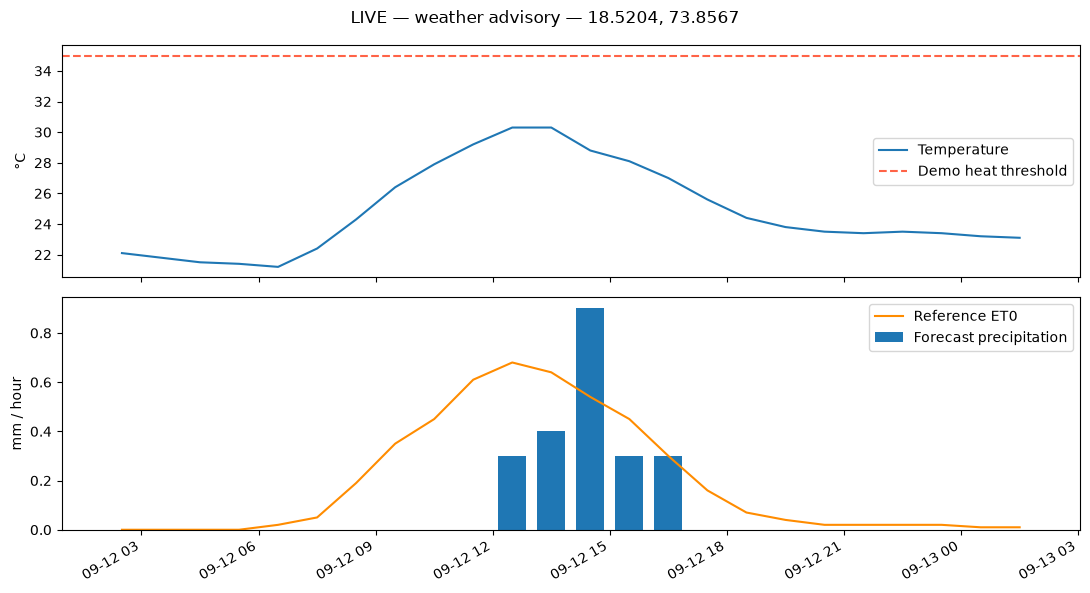

In [5]:
if MODE == "live":
    envelope = fetch_forecast(LATITUDE, LONGITUDE)
    reference_time = pd.Timestamp.now(tz="UTC")
elif MODE == "demo":
    envelope = demo_forecast()
    reference_time = DEMO_NOW
else:
    raise ValueError("MODE must be live or demo.")
forecast_window, forecast_metadata = parse_forecast(envelope, reference_time)
advisory = weather_advice(forecast_window, forecast_metadata)
display(advisory)
view = forecast_window.copy()
view["local_time"] = view.time.dt.tz_convert(LOCAL_TIMEZONE)
display(view[["local_time", *VARIABLES]].head(8))
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(view.local_time, view.temperature_2m, label="Temperature")
axes[0].axhline(RULES["heat_c"], color="tomato", linestyle="--", label="Demo heat threshold")
axes[0].set_ylabel("°C")
axes[0].legend()
axes[1].bar(view.local_time, view.precipitation, width=0.03, label="Forecast precipitation")
axes[1].plot(view.local_time, view.et0_fao_evapotranspiration, color="darkorange", label="Reference ET0")
axes[1].set_ylabel("mm / hour")
axes[1].legend()
fig.suptitle(f"{MODE.upper()} — weather advisory — {LATITUDE}, {LONGITUDE}")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## Export

Save the advisory, hourly series, and plot with the source, fetch time, validity period, units, and live/demo label.
Align weather intervals with the soil reading before passing them to irrigation.
The crop classifier's rainfall period is unresolved, so it cannot take this forecast directly.

In [6]:
output_dir = ROOT / "outputs/predictions"
figure_dir = ROOT / "outputs/figures"
output_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)
(output_dir / f"weather_advisory_{MODE}.json").write_text(
    json.dumps(advisory, indent=2, allow_nan=False), encoding="utf-8")
forecast_window.to_csv(output_dir / f"weather_hourly_{MODE}.csv", index=False)
fig.savefig(figure_dir / f"weather_forecast_{MODE}.png", dpi=160, bbox_inches="tight")
print("Saved weather artifacts for mode:", MODE)


Saved weather artifacts for mode: live
